# Guiding Vector Field (GVF) for Trajectory Tracking
This notebook demonstrates how to construct and visualize GVFs for:
- A circular trajectory
- A lemniscate (figure-eight) trajectory

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## GVF for Circular Path

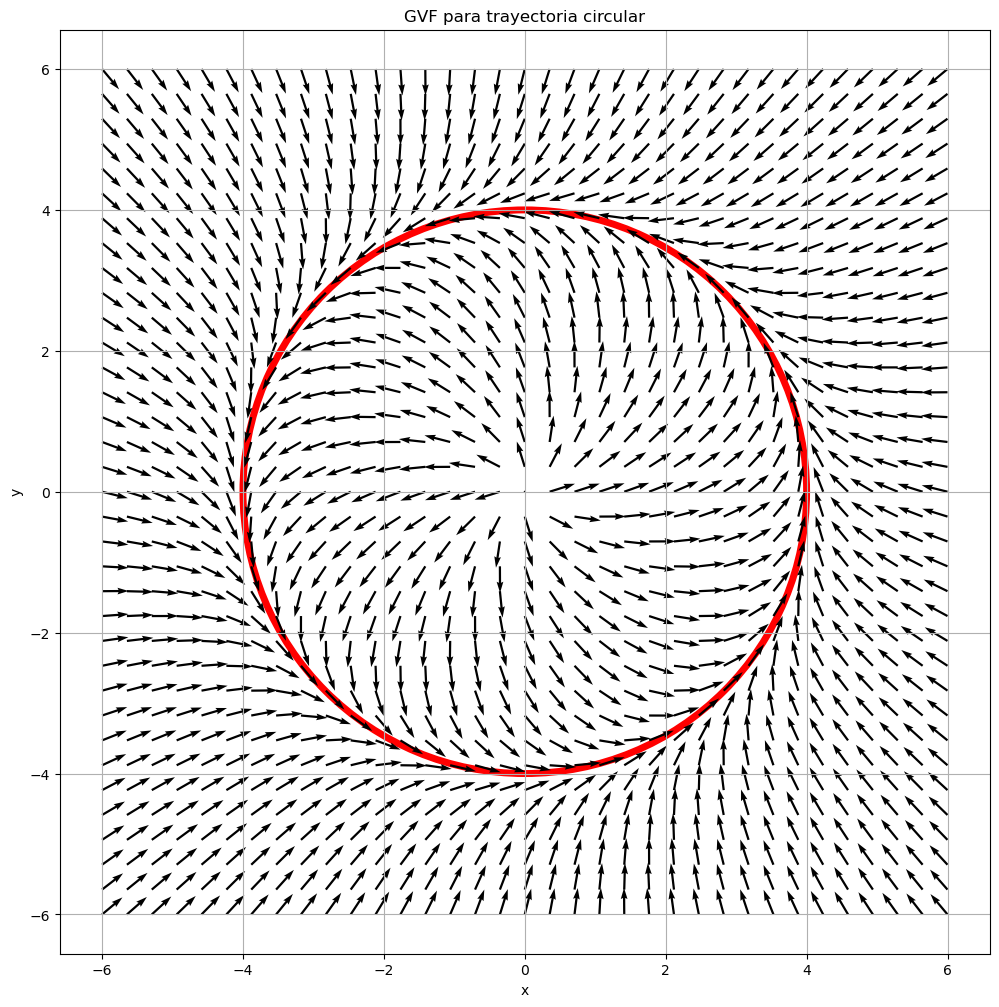

In [31]:
# Parameters
R = 4
k_e = 0.2

# Error function φ(x, y) = x² + y² - R²
def phi(x, y):
    return x**2 + y**2 - R**2

# Gradient of φ
def grad_phi(x, y):
    return np.array([2 * x, 2 * y])

# Tangent vector (90° CCW rotation of gradient)
def tangent(x, y):
    grad = grad_phi(x, y)
    return np.array([-grad[1], grad[0]])

# GVF field
def gvf(x, y):
    grad = grad_phi(x, y)
    tau = tangent(x, y)
    phi_val = phi(x, y)
    V = tau - k_e * phi_val * grad
    return V / np.linalg.norm(V) if np.linalg.norm(V) != 0 else np.zeros(2)

# Mesh grid
x_vals = np.linspace(-6, 6, 35)
y_vals = np.linspace(-6, 6, 35)
X, Y = np.meshgrid(x_vals, y_vals)
U, V = np.zeros_like(X), np.zeros_like(Y)

# Compute GVF field
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        vec = gvf(X[i, j], Y[i, j])
        U[i, j], V[i, j] = vec

# Plot
plt.figure(figsize=(12, 12))
plt.grid(True)
plt.gca().add_patch(plt.Circle((0, 0), R, color='r', fill=False, linewidth=5))
plt.quiver(X, Y, U, V, color='k', scale=35, pivot='tail')

plt.title("GVF para trayectoria circular")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

## GVF for Lemniscate of Bernoulli

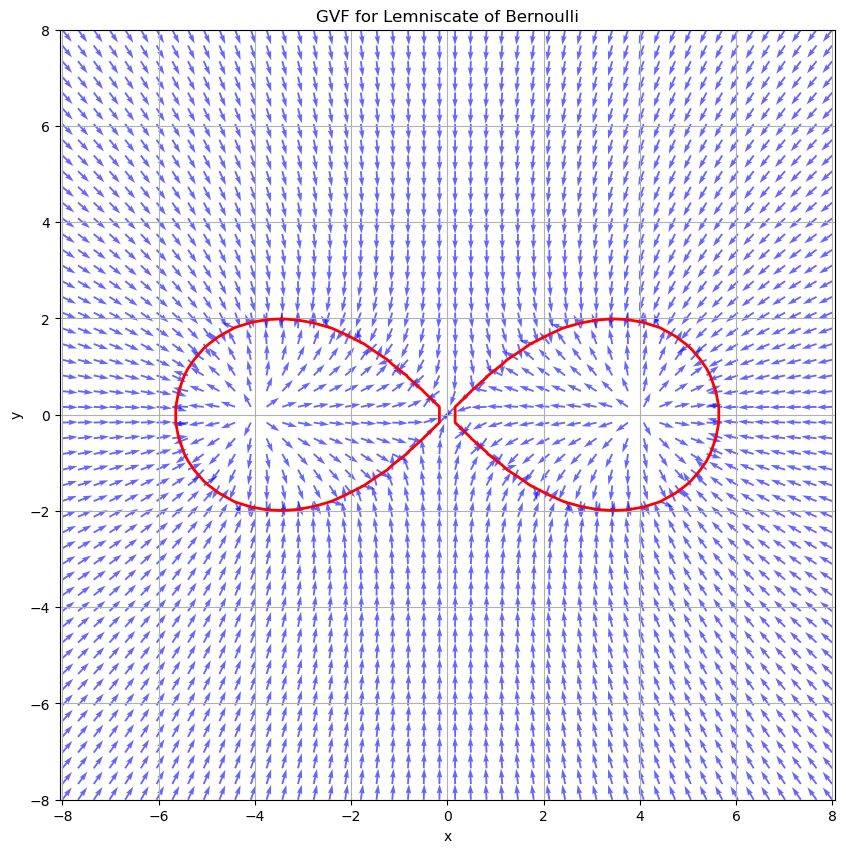

In [16]:
# Parameters
a = 4



# Error function for lemniscate
def phi_lemniscate(x, y):
    return (x**2 + y**2)**2 - 2 * a**2 * (x**2 - y**2)

# Gradient
def grad_phi_lemniscate(x, y):
    dphix = 4 * x * (x**2 + y**2) - 4 * a**2 * x
    dphiy = 4 * y * (x**2 + y**2) + 4 * a**2 * y
    return np.array([dphix, dphiy])

# Tangent vector
def tangent_lemniscate(x, y):
    grad = grad_phi_lemniscate(x, y)
    return np.array([-grad[1], grad[0]])

# GVF
def gvf_lemniscate(x, y):
    grad = grad_phi_lemniscate(x, y)
    tau = tangent_lemniscate(x, y)
    phi_val = phi_lemniscate(x, y)
    V = tau - k_e * phi_val * grad
    return V / np.linalg.norm(V) if np.linalg.norm(V) != 0 else np.zeros(2)

# Grid
x_vals = np.linspace(-8, 8, 50)
y_vals = np.linspace(-8, 8, 50)
X, Y = np.meshgrid(x_vals, y_vals)
U, V = np.zeros_like(X), np.zeros_like(Y)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        vec = gvf_lemniscate(X[i, j], Y[i, j])
        U[i, j], V[i, j] = vec

phi_vals = phi_lemniscate(X, Y)

# Plot
plt.figure(figsize=(10, 10))
plt.quiver(X, Y, U, V, color='blue', scale=50, pivot='tail', alpha=0.6)
plt.contour(X, Y, phi_vals, levels=[0], colors='r', linewidths=2)
plt.title("GVF for Lemniscate of Bernoulli")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()

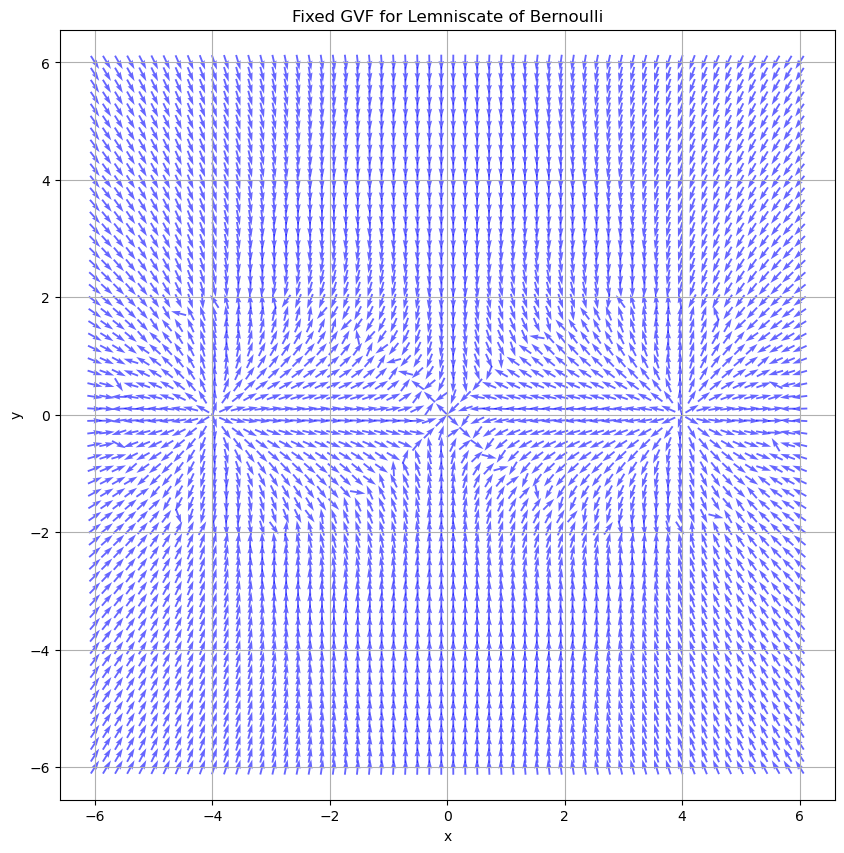

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 4
k_e = 0.5  # Adjusted scaling factor for GVF

# Error function for lemniscate
def phi_lemniscate(x, y):
    return (x**2 + y**2)**2 - 2 * a**2 * (x**2 - y**2)

# Gradient of error function
def grad_phi_lemniscate(x, y):
    dphix = 4 * x * (x**2 + y**2) - 4 * a**2 * x
    dphiy = 4 * y * (x**2 + y**2) + 4 * a**2 * y
    return np.array([dphix, dphiy])

# Tangent vector along the lemniscate
def tangent_lemniscate(x, y):
    grad = grad_phi_lemniscate(x, y)
    return np.array([-grad[1], grad[0]])

# GVF ensuring smooth trajectory flow along the lemniscate
def gvf_lemniscate(x, y):
    grad = grad_phi_lemniscate(x, y)
    tau = tangent_lemniscate(x, y)
    phi_val = phi_lemniscate(x, y)
    V = tau - k_e * phi_val * grad
    
    if np.linalg.norm(V) != 0:
        V = V / np.linalg.norm(V)  # Normalize to maintain smooth trajectory following
    
    return V

# Generate the grid for visualization
x_vals = np.linspace(-6, 6, 60)
y_vals = np.linspace(-6, 6, 60)
X, Y = np.meshgrid(x_vals, y_vals)
U, V = np.zeros_like(X), np.zeros_like(Y)

# Compute the vector field following the lemniscate path
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        vec = gvf_lemniscate(X[i, j], Y[i, j])
        U[i, j], V[i, j] = vec

# Generate contour for lemniscate curve
phi_vals = phi_lemniscate(X, Y)

# Plot
plt.figure(figsize=(10, 10))
#plt.contour(X, Y, phi_vals, levels=[0], colors='r', linewidths=2)  # Smooth red curve for trajectory
plt.quiver(X, Y, U, V, color='blue', scale=50, pivot='middle', alpha=0.6)  # Arrows now follow the curve correctly
plt.title("Fixed GVF for Lemniscate of Bernoulli")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()
